<a href="https://colab.research.google.com/github/shriya-0802/KneeOsteoArthritis/blob/main/Densenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python-headless

In [2]:
!pip install tensorflow

In [3]:
# =========================
# BASIC LIBRARIES
# =========================
import numpy as np
import pandas as pd
import os
import time
import shutil
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# SKLEARN
# =========================
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# =========================
# TENSORFLOW / KERAS
# =========================
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.layers import (
    Dense, Activation, Dropout, Conv2D,
    MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Input
)


from tensorflow.keras.optimizers import Adam, SGD, Adamax

from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K

# =========================
# PRETRAINED MODEL
# =========================
from tensorflow.keras.applications import DenseNet121


In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
train_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/train'
test_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/test'
valid_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/val'
list_of_classes=['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

In [6]:
# def median_noise_removal(image):
#     median = cv2.medianBlur(image, 5)
#     return cv2.absdiff(image, median)

# for i in range(3):
#   folname = valid_path+'/'+str(i)
#   for filename in os.listdir(folname):
#       if filename.endswith(".jpg") or filename.endswith(".png"):
#           image = cv2.imread(os.path.join(folname, filename))
#           image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#           denoised_image = median_noise_removal(image)
#           cv2.imwrite("denoised_" + filename, denoised_image)

# # Create CLAHE object
# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# # Folder containing X-ray images
# for i in range(3):
#   folname = valid_path+'/'+str(i)
#   # Loop through all the images in the folder
#   for filename in os.listdir(folname):
#       #print(filename)
#       # Check if the file is an image
#       if filename.endswith(".jpg") or filename.endswith(".png"):
#           # Load X-ray image
#           img = cv2.imread(os.path.join(folname, filename), 0)

#           # Apply CLAHE to the X-ray image
#           img_clahe = clahe.apply(img)

#           # Save the result
#           cv2.imwrite(os.path.join(folname, filename), img_clahe)

In [7]:
for d in [train_path, test_path, valid_path]:
    filepaths = []
    labels=[]
    classlist=os.listdir(d)
    for klass in classlist:
        intklass=int(klass)
        label=list_of_classes[intklass]
        classpath=os.path.join(d, klass)
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(label)
    Fseries=pd.Series(filepaths, name='filepaths')
    Lseries=pd.Series(labels, name='labels')
    pdf=pd.concat([Fseries, Lseries], axis=1)
    if d == test_path:
        test_df=pdf
    elif d == valid_path:
        valid_df=pdf
    else:
        train_df=pdf
print('train_df lenght: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))
# get the number of classes and the images count for each class in train_df
classes=sorted(list(train_df['labels'].unique()))
class_count = len(classes)
print('The number of classes in the dataset is: ', class_count)
groups=train_df.groupby('labels')
print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))
countlist=[]
classlist=[]
for label in sorted(list(train_df['labels'].unique())):
    group=groups.get_group(label)
    countlist.append(len(group))
    classlist.append(label)
    print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

# get the classes with the minimum and maximum number of train images
max_value=np.max(countlist)
max_index=countlist.index(max_value)
max_class=classlist[max_index]
min_value=np.min(countlist)
min_index=countlist.index(min_value)
min_class=classlist[min_index]
print(max_class, ' has the most images= ',max_value, ' ', min_class, ' has the least images= ', min_value)
# lets get the average height and width of a sample of the train images
ht=0
wt=0
# select 100 random samples of train_df
train_df_sample=train_df.sample(n=100, random_state=123,axis=0)
for i in range (len(train_df_sample)):
    fpath=train_df_sample['filepaths'].iloc[i]
    img=plt.imread(fpath)
    shape=img.shape
    ht += shape[0]
    wt += shape[1]
print('average height= ', ht//100, ' average width= ', wt//100, 'aspect ratio= ', ht/wt)

train_df lenght:  5790   test_df length:  1656   valid_df length:  826
The number of classes in the dataset is:  5
            CLASS               IMAGE COUNT 
           Doubtful                1046     
           Healthy                 2298     
           Minimal                 1516     
           Moderate                 757     
            Severe                  173     
Healthy  has the most images=  2298   Severe  has the least images=  173
average height=  224  average width=  224 aspect ratio=  1.0


In [8]:
def trim(df, max_samples, min_samples, column):
    df=df.copy()
    groups=df.groupby(column)
    trimmed_df = pd.DataFrame(columns = df.columns)
    groups=df.groupby(column)
    for label in df[column].unique():
        group=groups.get_group(label)
        count=len(group)
        if count > max_samples:
            sampled_group=group.sample(n=max_samples, random_state=123,axis=0)
            trimmed_df=pd.concat([trimmed_df, sampled_group], axis=0)
        else:
            if count>=min_samples:
                sampled_group=group
                trimmed_df=pd.concat([trimmed_df, sampled_group], axis=0)
    print('after trimming, the maximum samples in any class is now ',max_samples, ' and the minimum samples in any class is ', min_samples)
    return trimmed_df

max_samples=500 # since each class has more than 200 images all classes will be trimmed to have 200 images per class
min_samples=173
column='labels'
train_df= trim(train_df, max_samples, min_samples, column)

after trimming, the maximum samples in any class is now  500  and the minimum samples in any class is  173


In [9]:
def balance(df, n, working_dir, img_size):
    df=df.copy()
    print('Initial length of dataframe is ', len(df))
    aug_dir=os.path.join(working_dir, 'aug')# directory to store augmented images
    if os.path.isdir(aug_dir):# start with an empty directory
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)
    for label in df['labels'].unique():
        dir_path=os.path.join(aug_dir,label)
        os.mkdir(dir_path) # make class directories within aug directory
    # create and store the augmented images
    total=0
    gen=ImageDataGenerator(horizontal_flip=True,  rotation_range=20, width_shift_range=.2,height_shift_range=.2, zoom_range=.2)
    groups=df.groupby('labels') # group by class
    for label in df['labels'].unique():  # for every class
        group=groups.get_group(label)  # a dataframe holding only rows with the specified label
        sample_count=len(group)   # determine how many samples there are in this class
        if sample_count< n: # if the class has less than target number of images
            aug_img_count=0
            delta=n - sample_count  # number of augmented images to create
            target_dir=os.path.join(aug_dir, label)  # define where to write the images
            msg='{0:40s} for class {1:^30s} creating {2:^5s} augmented images'.format(' ', label, str(delta))
            print(msg, '\r', end='') # prints over on the same line
            aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=img_size,
                                            class_mode=None, batch_size=1, shuffle=False,
                                            save_to_dir=target_dir, save_prefix='aug-', color_mode='rgb',
                                            save_format='jpg')
            while aug_img_count<delta:
                images=next(aug_gen)
                aug_img_count += len(images)
            total +=aug_img_count
    print('Total Augmented images created= ', total)
    # create aug_df and merge with train_df to create composite training set ndf
    aug_fpaths=[]
    aug_labels=[]
    classlist=os.listdir(aug_dir)
    for klass in classlist:
        classpath=os.path.join(aug_dir, klass)
        flist=os.listdir(classpath)
        for f in flist:
          fpath=os.path.join(classpath,f)
          aug_fpaths.append(fpath)
          aug_labels.append(klass)
    Fseries=pd.Series(aug_fpaths, name='filepaths')
    Lseries=pd.Series(aug_labels, name='labels')
    aug_df=pd.concat([Fseries, Lseries], axis=1)
    df=pd.concat([df,aug_df], axis=0).reset_index(drop=True)
    print('Length of augmented dataframe is now ', len(df))
    return df

n=500 # number of samples in each class
working_dir=r'./' # directory to store augmented images
img_size=(224,224) # size of augmented images
train_df=balance(train_df, n, working_dir, img_size)

Initial length of dataframe is  2173
Found 173 validated image filenames.
Total Augmented images created=  327
Length of augmented dataframe is now  2500


In [10]:
def relabel(label_in):
    if label_in =='Healthy' or label_in == 'Doubtful' or label_in =='Minimal':
        label='Healthy'
    else:
        label=label_in
    return label


for df in [train_df, test_df, valid_df]:
    for i in range (len(df)):
        label=df['labels'].iloc[i]
        new_label=relabel(label)
        df['labels'].iloc[i]=new_label
print (train_df['labels'].value_counts())

/tmp/ipykernel_2864/2821975925.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['labels'].iloc[i]=new_label


labels
Healthy     1500
Severe       500
Moderate     500
Name: count, dtype: int64


In [11]:
max_samples=500 # since each class has more than 200 images all classes will be trimmed to have 200 images per class
min_samples=500
column='labels'
train_df= trim(train_df, max_samples, min_samples, column)

after trimming, the maximum samples in any class is now  500  and the minimum samples in any class is  500


In [12]:
batch_size=20 # We will use and EfficientetB3 model, with image size of (200, 250) this size should not cause resource error
trgen=ImageDataGenerator(horizontal_flip=True,rotation_range=20 )
t_and_v_gen=ImageDataGenerator()
msg='{0:70s} for train generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
train_gen=trgen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)
msg='{0:70s} for valid generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
valid_gen=t_and_v_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size)
# for the test_gen we want to calculate the batch size and test steps such that batch_size X test_steps= number of samples in test set
# this insures that we go through all the sample in the test set exactly once.
length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]
test_steps=int(length/test_batch_size)
msg='{0:70s} for test generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
test_gen=t_and_v_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=test_batch_size)
# from the generator we can get information we will need later
classes=list(train_gen.class_indices.keys())
class_indices=list(train_gen.class_indices.values())
class_count=len(classes)
labels=test_gen.labels
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps, ' number of classes : ', class_count)

Found 1500 validated image filenames belonging to 3 classes.
Found 826 validated image filenames belonging to 3 classes.
Found 1656 validated image filenames belonging to 3 classes.
test batch size:  72   test steps:  23  number of classes :  3


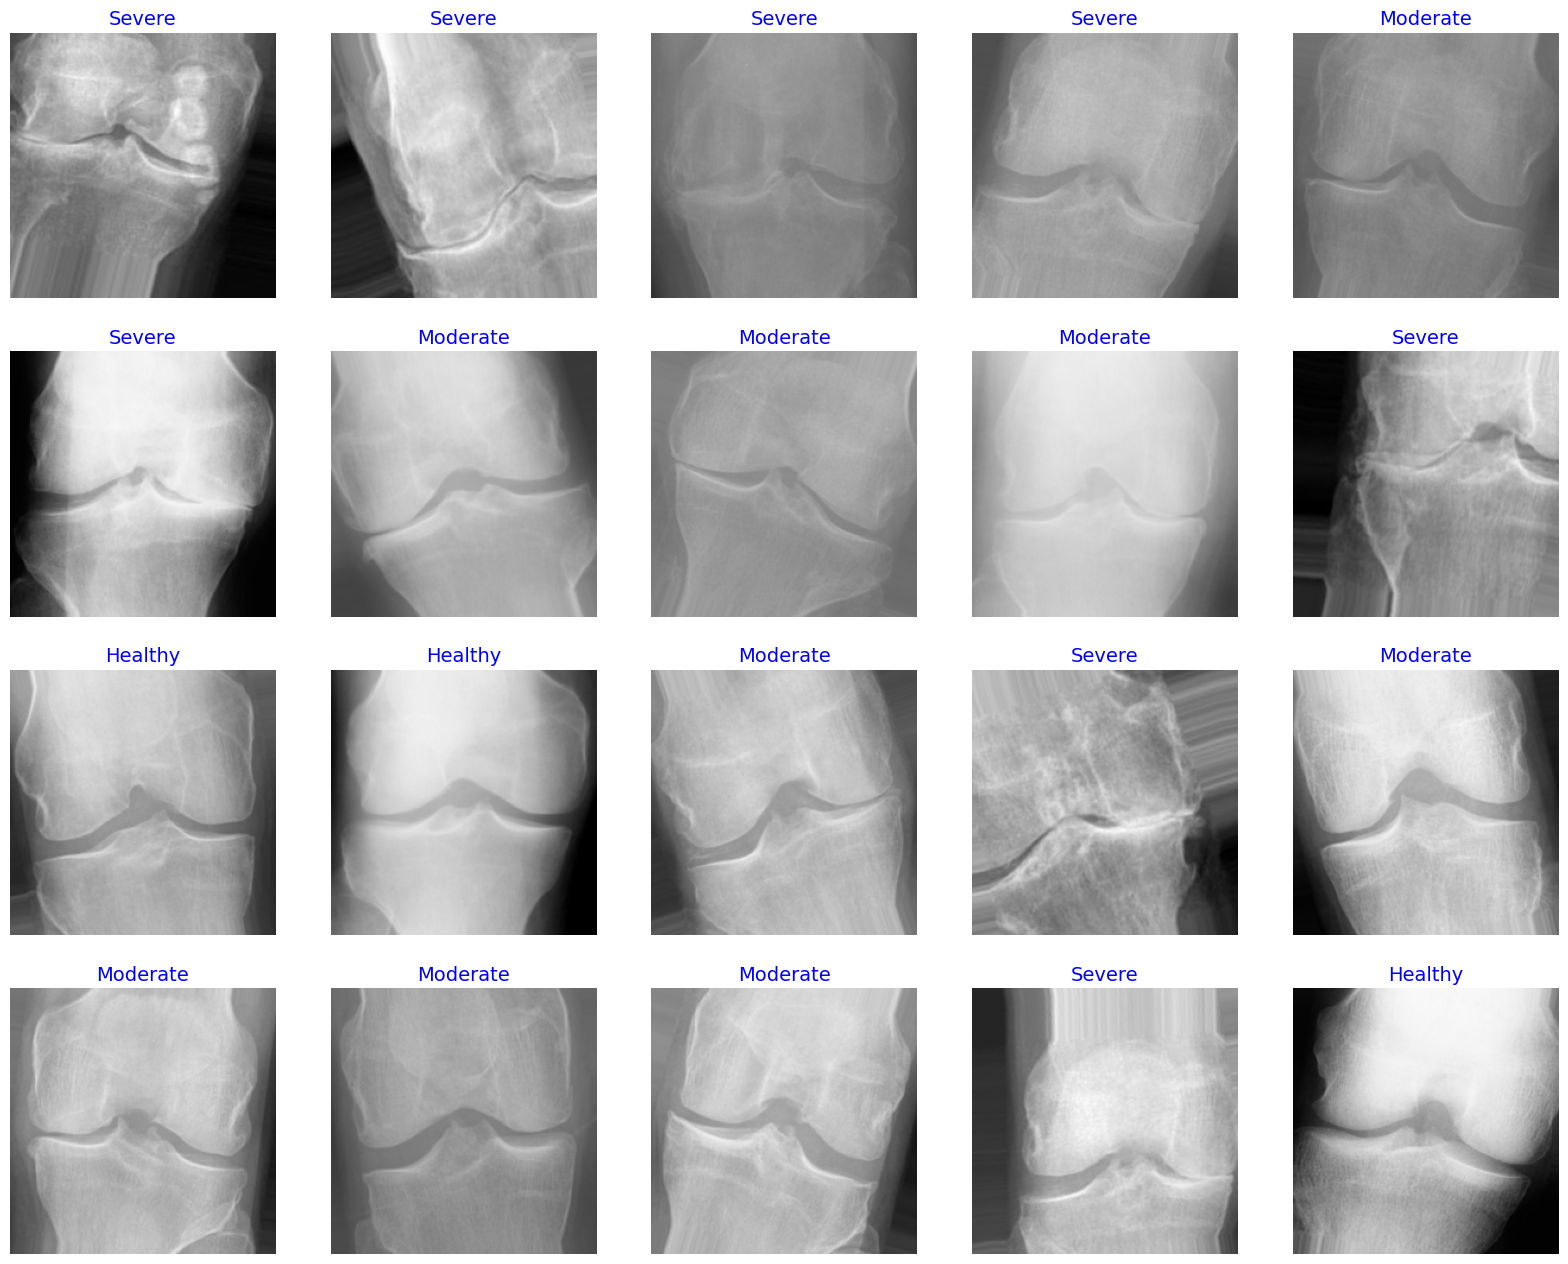

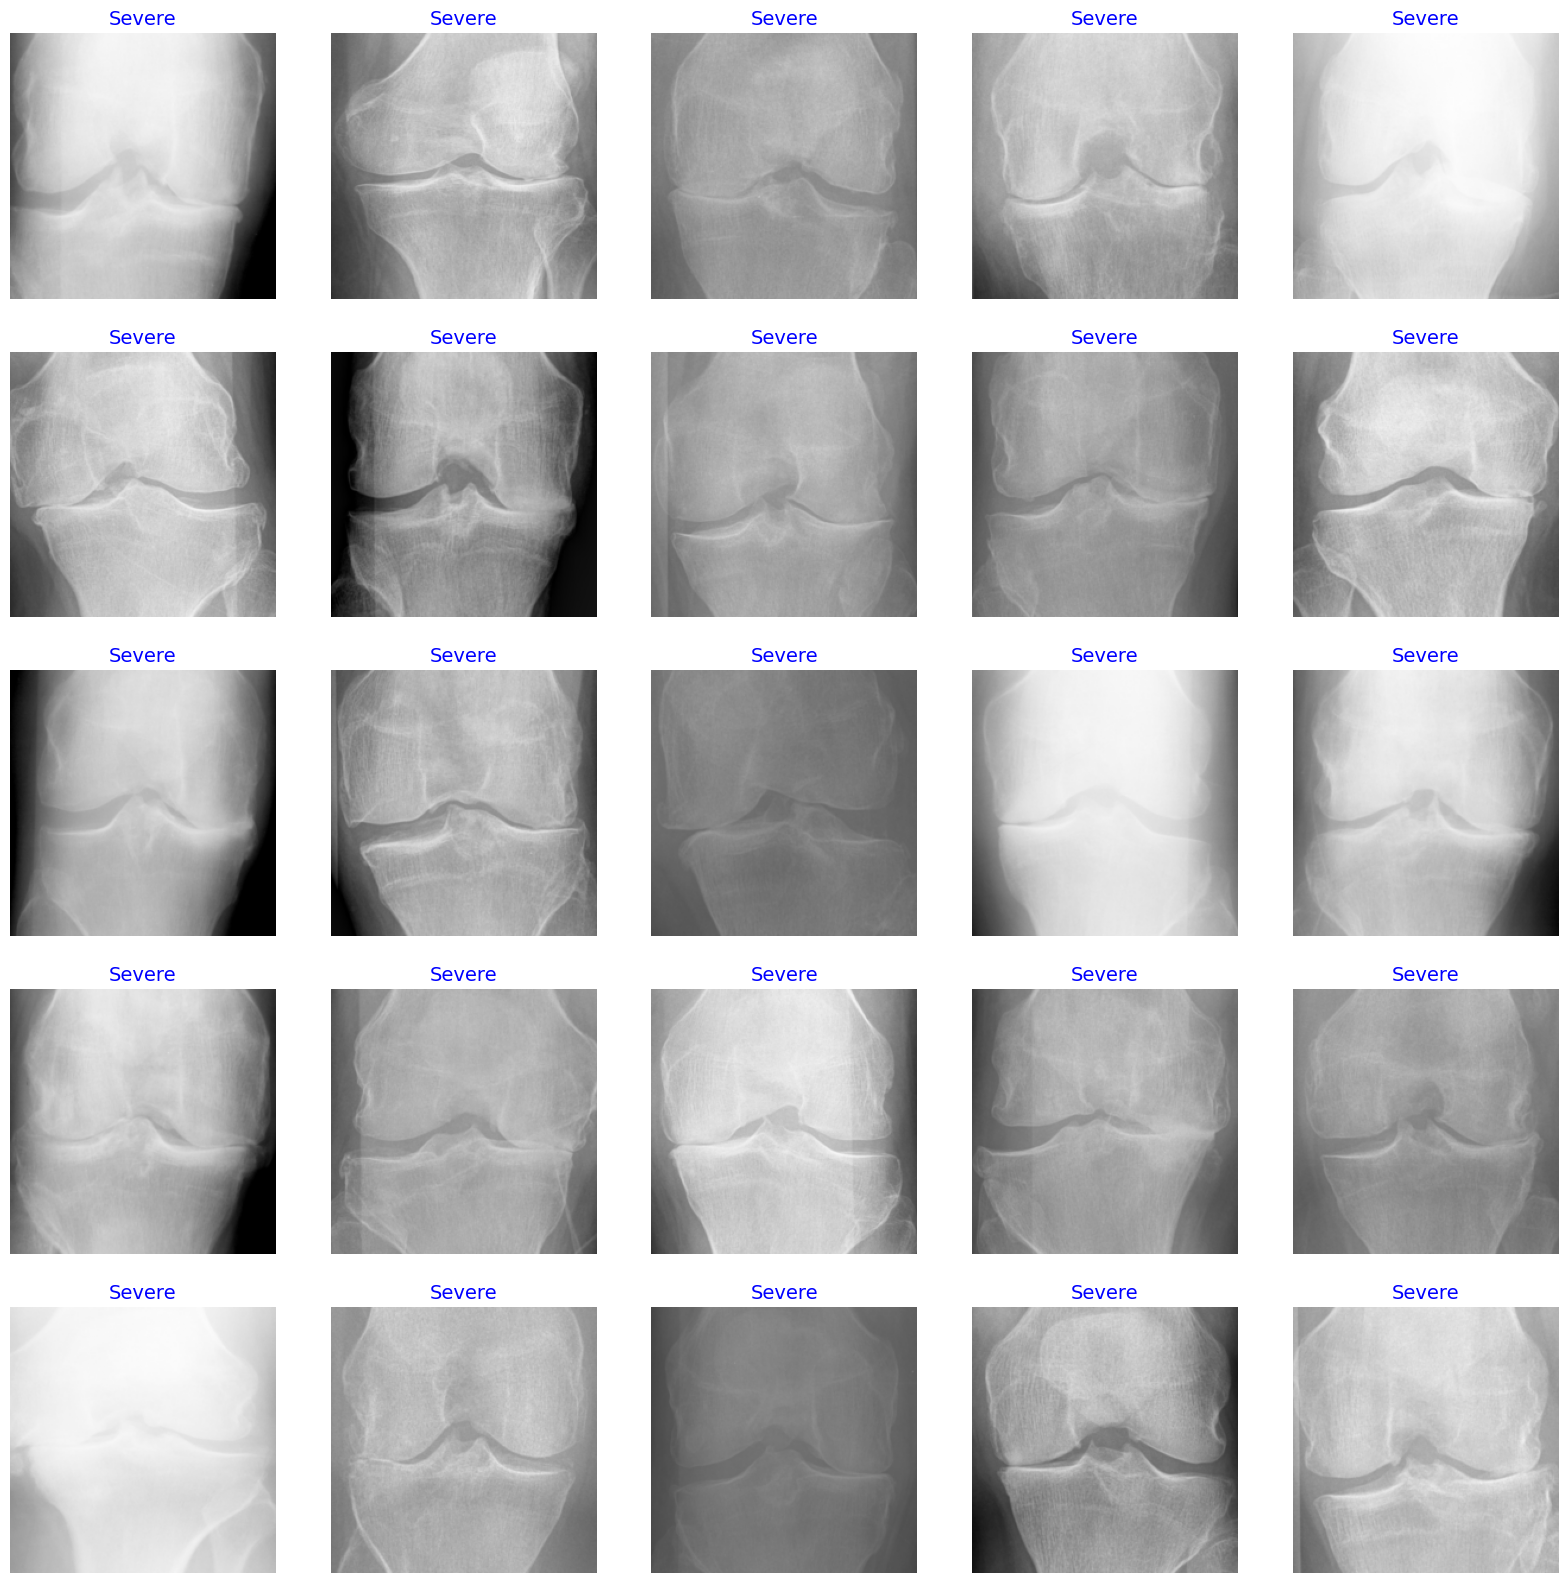

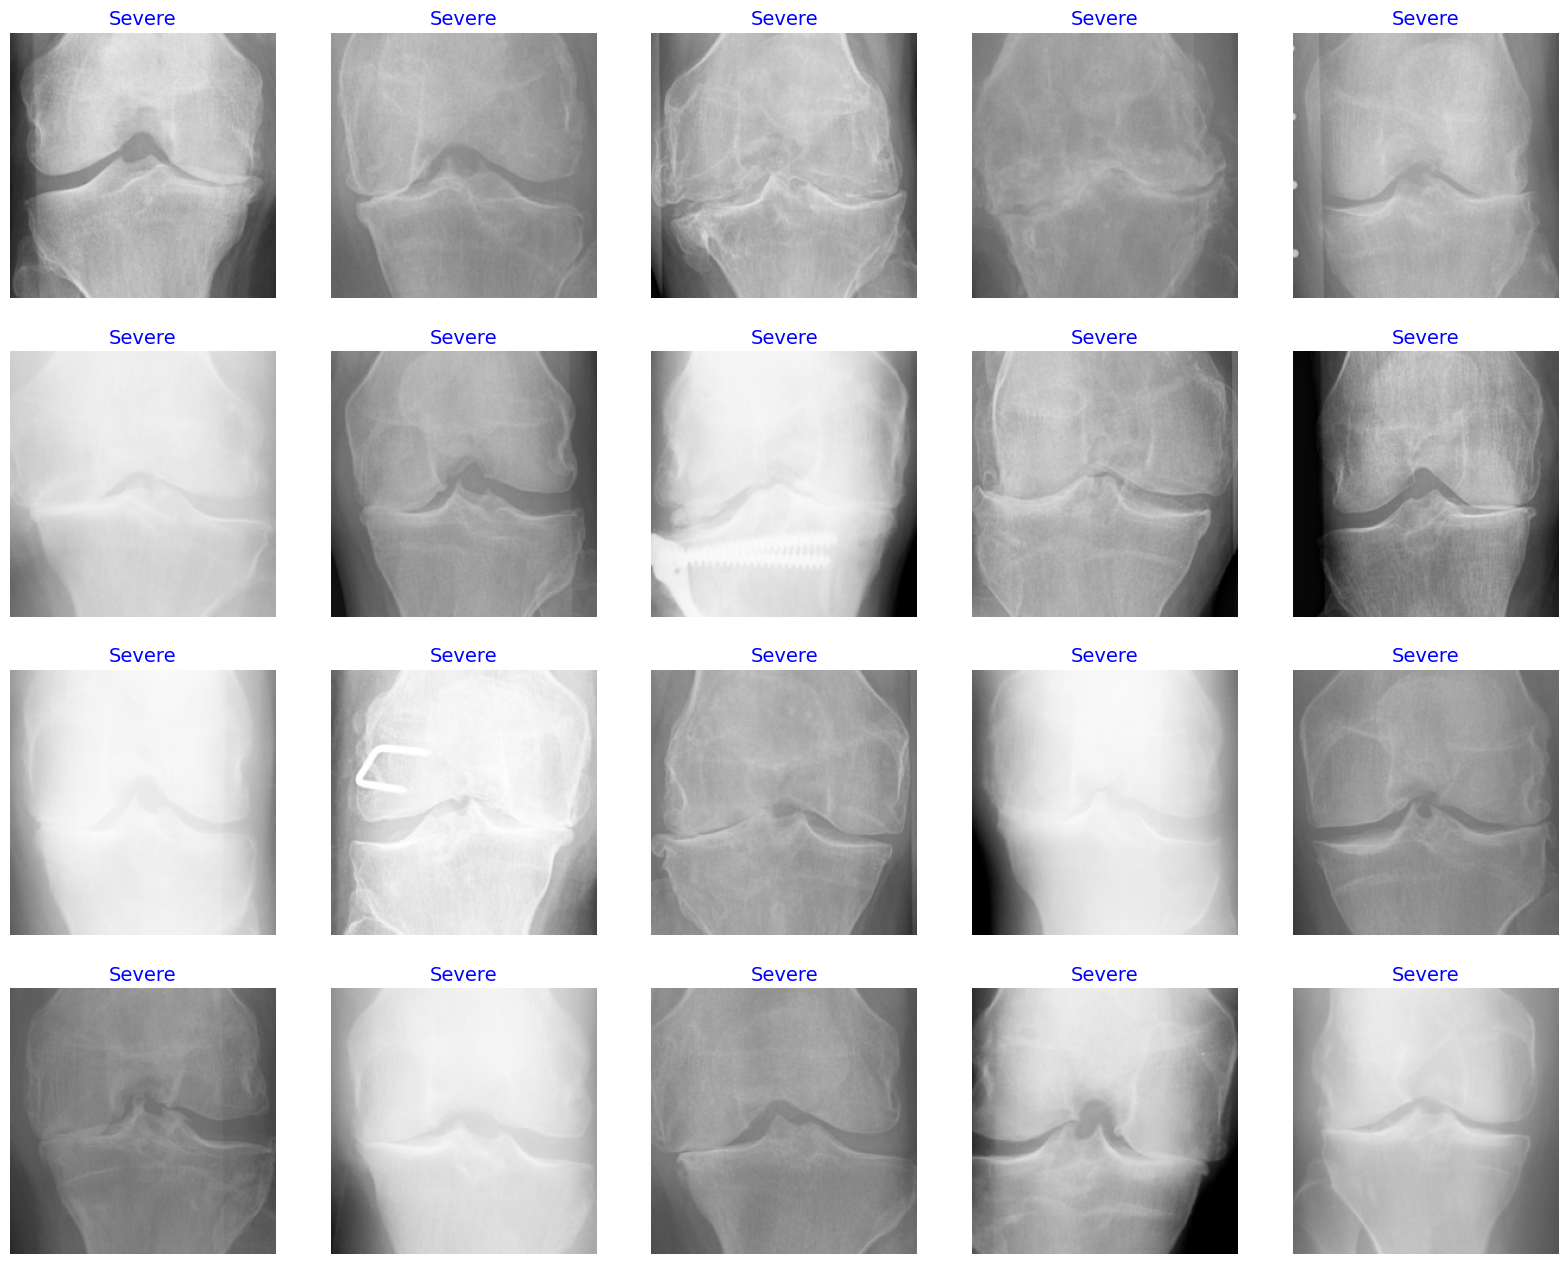

In [13]:
def show_image_samples(gen ):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())
    images,labels=next(gen) # get a sample batch from the generator
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<25:   #show maximum of 25 images
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=images[i] /255
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=14)
        plt.axis('off')
    plt.show()

show_image_samples(train_gen )
show_image_samples(test_gen )
show_image_samples(valid_gen )

In [14]:
input_tensor = Input(shape=(224, 224, 3))

base_model = DenseNet121(weights='imagenet',
                         include_top=False,
                         input_shape=(224,224,3),
                         pooling='max')

base_model.trainable = True

x = base_model.output

x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

x = Dense(256,
          kernel_regularizer=regularizers.l2(0.016),   # ✅ FIXED HERE
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006),
          activation='relu')(x)

x = Dropout(rate=.4, seed=123)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

lr = .001

model.compile(Adamax(learning_rate=lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
class LR_ASK(keras.callbacks.Callback):
    def __init__(self, epochs, ask_epoch):  # ✅ FIXED (removed model)
        super(LR_ASK, self).__init__()
        self.ask_epoch = ask_epoch
        self.epochs = epochs
        self.ask = True
        self.lowest_vloss = np.inf
        self.best_weights = None   # ✅ FIXED
        self.best_epoch = 1

    def on_train_begin(self, logs=None):
        self.best_weights = self.model.get_weights()  # ✅ moved here

        if self.ask_epoch == 0:
            print('you set ask_epoch = 0, ask_epoch will be set to 1', flush=True)
            self.ask_epoch = 1

        if self.ask_epoch >= self.epochs:
            print('ask_epoch >= epochs, will train for ', self.epochs, ' epochs', flush=True)
            self.ask = False

        if self.epochs == 1:
            self.ask = False
        else:
            print('Training will proceed until epoch', self.ask_epoch, ' then you will be asked to')
            print(' enter H to halt training or enter an integer for how many more epochs to run then be asked again')

        self.start_time = time.time()

    def on_train_end(self, logs=None):
        print('loading model with weights from epoch ', self.best_epoch)
        self.model.set_weights(self.best_weights)

        tr_duration = time.time() - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))

        print(f'training elapsed time was {int(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds', flush=True)

    def on_epoch_end(self, epoch, logs=None):
        v_loss = logs.get('val_loss')

        if v_loss < self.lowest_vloss:
            self.lowest_vloss = v_loss
            self.best_weights = self.model.get_weights()
            self.best_epoch = epoch + 1
            print(f'\n validation loss of {v_loss:7.4f} is below lowest loss, saving weights from epoch {epoch+1}')
        else:
            print(f'\n validation loss of {v_loss:7.4f} is above lowest loss of {self.lowest_vloss:7.4f}')

        if self.ask and (epoch + 1 == self.ask_epoch):
            print('\n Enter H to end training or integer for more epochs')
            ans = input()

            if ans in ['H', 'h', '0']:
                print('Training halted by user')
                self.model.stop_training = True
            else:
                self.ask_epoch += int(ans)

                lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))  # ✅ FIXED (.lr → .learning_rate)
                print(f'current LR is {lr:.5f}, press enter to keep or enter new LR')

                ans = input()
                if ans != '':
                    tf.keras.backend.set_value(self.model.optimizer.learning_rate, float(ans))
                    print('LR updated to', ans)

In [16]:
epochs = 20
ask_epoch = 10

ask = LR_ASK(epochs, ask_epoch)

callbacks = [ask]

In [17]:
new_history = model.fit(x=train_gen,  epochs=epochs, verbose=1, callbacks=callbacks,  validation_data=valid_gen,
               validation_steps=None,  shuffle=False,  initial_epoch=0
)


Training will proceed until epoch 10  then you will be asked to
 enter H to halt training or enter an integer for how many more epochs to run then be asked again
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4650 - loss: 13.4677
 validation loss of 29.2941 is below lowest loss, saving weights from epoch 1
75/75 ━━━━━━━━━━━━━━━━━━━━ 960s 12s/step - accuracy: 0.4940 - loss: 9.5418 - val_accuracy: 0.1029 - val_loss: 29.2941
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4649 - loss: 5.4538
 validation loss of  9.8041 is below lowest loss, saving weights from epoch 2
75/75 ━━━━━━━━━━━━━━━━━━━━ 776s 10s/step - accuracy: 0.4760 - loss: 5.2145 - val_accuracy: 0.2252 - val_loss: 9.8041
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4345 - loss: 4.6336
 validation loss of  5.6983 is below lowest loss, saving weights from epoch 3
75/75 ━━━━━━━━━━━━━━━━━━━━ 760s 10s/step - accuracy: 0.4400 - loss: 4.4881 - val_accuracy: 0.2361 - val_loss: 5.6983
Ep

In [18]:
def predictor(test_gen, test_steps):
    y_pred= []
    y_true=test_gen.labels
    classes=list(test_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, verbose=1)
    tests=len(preds)
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=test_gen.labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            errors=errors + 1
            file=test_gen.filenames[i]
        y_pred.append(pred_index)

    acc=( 1-errors/tests) * 100
    print(f'there were {errors} errors in {tests} tests for an accuracy of {acc:6.2f}')
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(12, 8))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    return errors, tests

23/23 ━━━━━━━━━━━━━━━━━━━━ 392s 17s/step
there were 644 errors in 1656 tests for an accuracy of  61.11


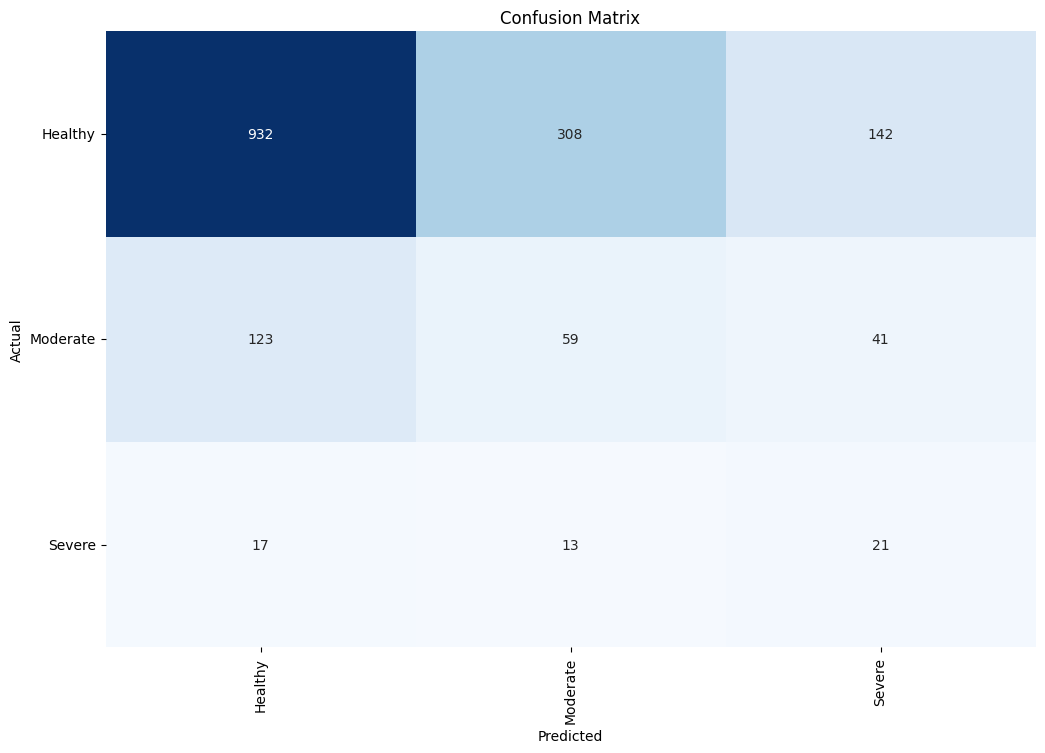

Classification Report:
----------------------
               precision    recall  f1-score   support

     Healthy     0.8694    0.6744    0.7596      1382
    Moderate     0.1553    0.2646    0.1957       223
      Severe     0.1029    0.4118    0.1647        51

    accuracy                         0.6111      1656
   macro avg     0.3759    0.4502    0.3733      1656
weighted avg     0.7496    0.6111    0.6653      1656



In [19]:
errors, tests=predictor(test_gen, test_steps)

In [20]:
new_history = model.fit(x=train_gen,  epochs=10, verbose=1, callbacks=callbacks,  validation_data=valid_gen,
               validation_steps=None,  shuffle=False,  initial_epoch=0
)

Training will proceed until epoch 10  then you will be asked to
 enter H to halt training or enter an integer for how many more epochs to run then be asked again
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4764 - loss: 2.1318
 validation loss of  2.0296 is below lowest loss, saving weights from epoch 1
75/75 ━━━━━━━━━━━━━━━━━━━━ 737s 10s/step - accuracy: 0.4767 - loss: 2.0902 - val_accuracy: 0.7349 - val_loss: 2.0296
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5050 - loss: 1.9824
 validation loss of  1.8978 is below lowest loss, saving weights from epoch 2
75/75 ━━━━━━━━━━━━━━━━━━━━ 737s 10s/step - accuracy: 0.4853 - loss: 1.9469 - val_accuracy: 0.7712 - val_loss: 1.8978
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4655 - loss: 1.8414
 validation loss of  1.7803 is below lowest loss, saving weights from epoch 3
75/75 ━━━━━━━━━━━━━━━━━━━━ 725s 10s/step - accuracy: 0.4780 - loss: 1.8077 - val_accuracy: 0.8136 - val_loss: 1.7803
Epoc

23/23 ━━━━━━━━━━━━━━━━━━━━ 185s 8s/step
there were 260 errors in 1656 tests for an accuracy of  84.30


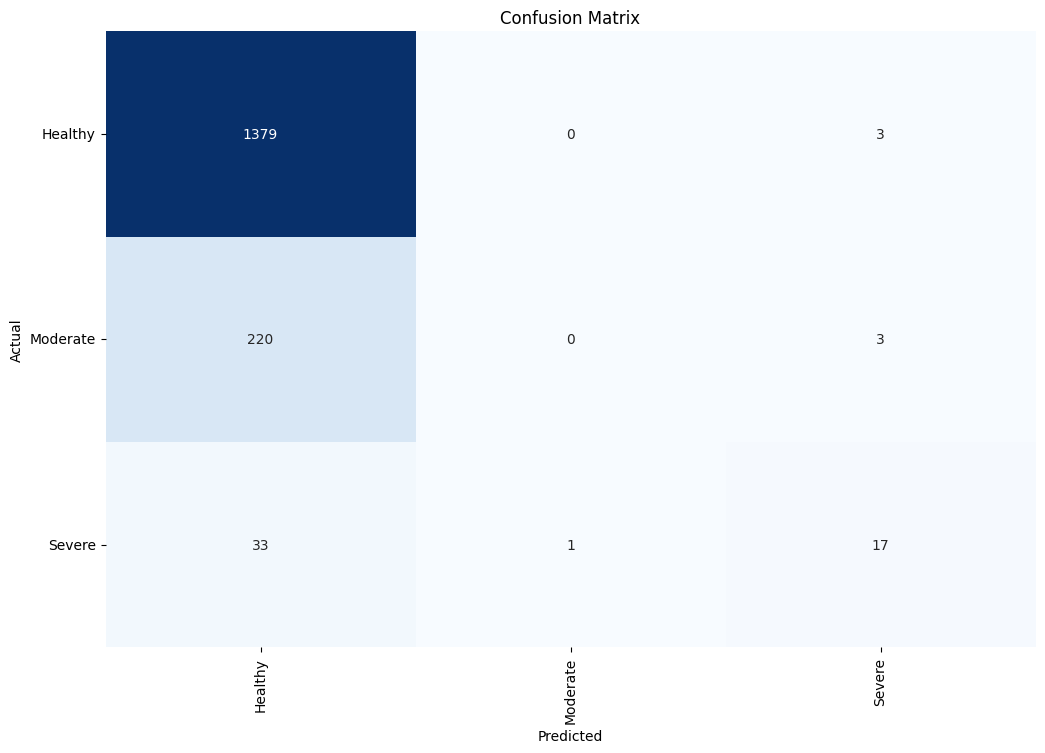

Classification Report:
----------------------
               precision    recall  f1-score   support

     Healthy     0.8450    0.9978    0.9151      1382
    Moderate     0.0000    0.0000    0.0000       223
      Severe     0.7391    0.3333    0.4595        51

    accuracy                         0.8430      1656
   macro avg     0.5280    0.4437    0.4582      1656
weighted avg     0.7279    0.8430    0.7778      1656



In [21]:
errors, tests=predictor(test_gen, test_steps)

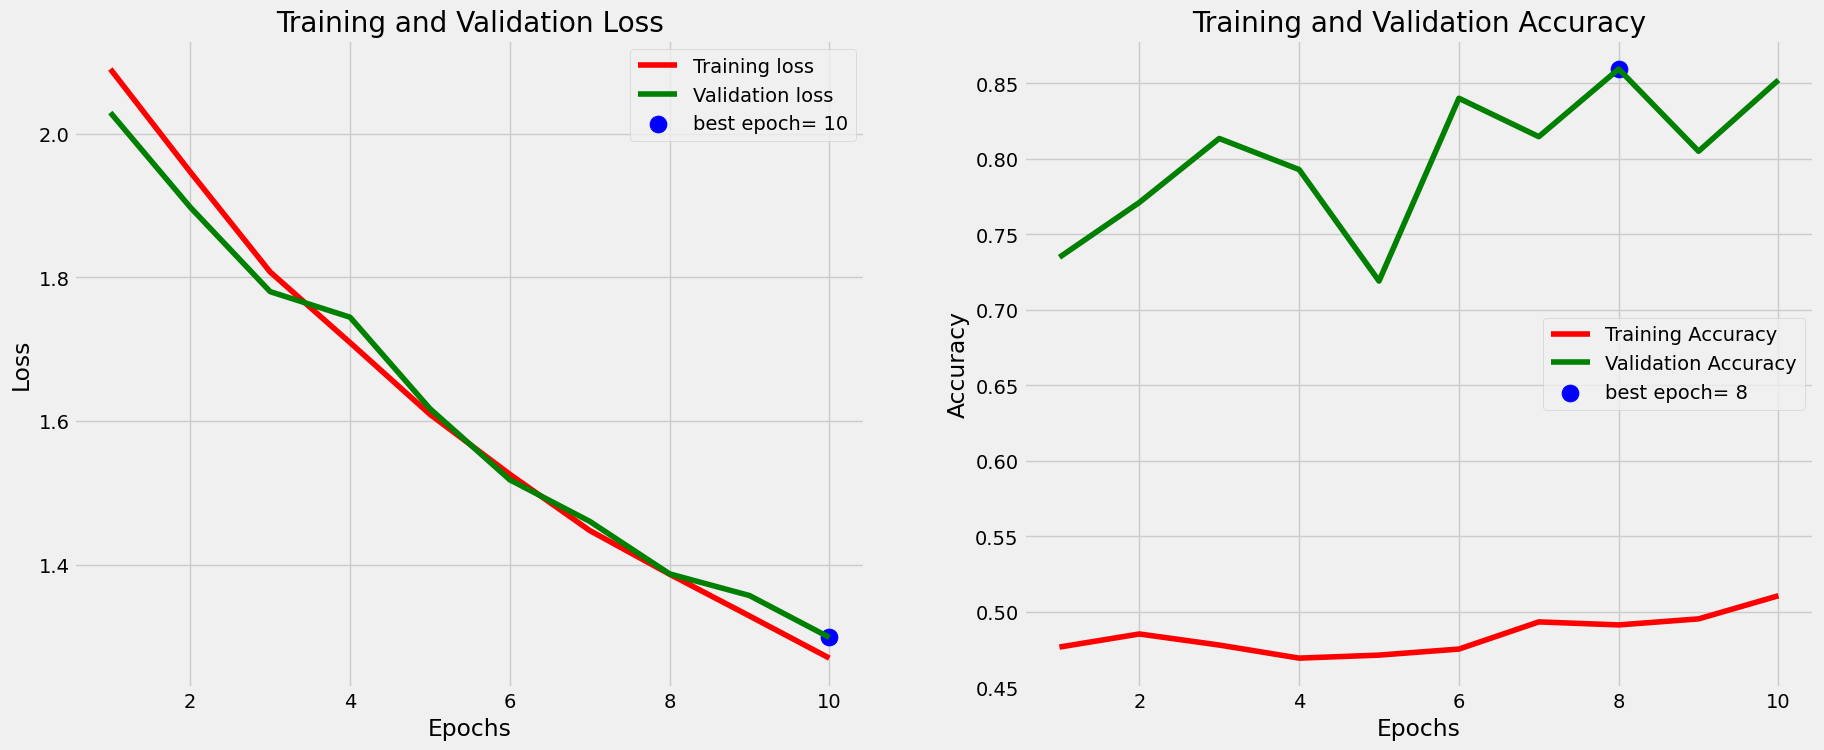

In [22]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

tr_plot(new_history,0)

In [23]:
subject='DenseNet'
acc=str(( 1-errors/tests) * 100)
index=acc.rfind('.')
acc=acc[:index + 3]
save_id= subject + '_' + str(acc) + '.h5'
model_save_loc=os.path.join("/content/drive/MyDrive/Colab Notebooks/", save_id)
model.save(model_save_loc)
print ('model was saved as ' , model_save_loc)

model was saved as  /content/drive/MyDrive/Colab Notebooks/DenseNet_84.29.h5
